### torch

In [118]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

### creating our plot function

In [226]:
def plt_predict(x=x_train, y=y_train, xt=x_test, yt=y_test, predictions=None):
    plt.scatter(x, y, label='Train data', color='green')
    plt.scatter(xt, yt, label='Test data', color='blue')
    
    if predictions is not None:
        plt.plot(xt, predictions, label='Prediction', color='red', linestyle='--')
    
    plt.legend()
    plt.show()

### creating our data set

In [227]:
weight=0.2
bias=0.3
x=torch.linspace(0,1,50).unsqueeze(dim=1)
y=weight*x + bias
split=int(0.8*len(x))
x_train=x[:split]
y_train=y[:split]
x_test=x[split:]
y_test=y[split:]

# plt_predict(x_train,y_train,x_test,y_test)

 ### creating our model subclassing nn.Module

In [228]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        # creating layers
        self.linear_layer=nn.Linear(in_features=1,out_features=1)
    #creating forward function
    def forward(self,x):
        return self.linear_layer(x)
# set a manual seed
torch.manual_seed(42)
ourModel=LinearModel()
print(ourModel,ourModel.state_dict())

LinearModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
) OrderedDict([('linear_layer.weight', tensor([[0.7645]])), ('linear_layer.bias', tensor([0.8300]))])


### training loop

In [229]:

epoches=3000
#loss
loss_fn=nn.L1Loss()
#optimizer
optimizer=torch.optim.SGD(params=ourModel.parameters(),lr=0.01)
for epoch in range(epoches):
    ourModel.train() 
    y_pred=ourModel(x_train)#forward pass 
    loss=loss_fn(y_pred,y_train)#loss
    optimizer.zero_grad() # optimizer zero grad
    loss.backward()  # back propagation
    optimizer.step() #optimizer step
    ourModel.eval() ## testing our model
    with torch.inference_mode():
        test_pred= ourModel(x_test)
        test_loss= loss_fn(test_pred,y_test)
    if epoch%500==0:
        print(f"epoch :{epoch} | loss : {loss} | test loss : {test_loss}")


epoch :0 | loss : 0.7546711564064026 | test loss : 1.029086947441101
epoch :500 | loss : 0.008464962244033813 | test loss : 0.005825355648994446
epoch :1000 | loss : 0.008464962244033813 | test loss : 0.005825355648994446
epoch :1500 | loss : 0.008464962244033813 | test loss : 0.005825355648994446
epoch :2000 | loss : 0.008464962244033813 | test loss : 0.005825355648994446
epoch :2500 | loss : 0.008464962244033813 | test loss : 0.005825355648994446


In [230]:
ourModel.state_dict(),weight,bias

(OrderedDict([('linear_layer.weight', tensor([[0.2013]])),
              ('linear_layer.bias', tensor([0.2910]))]),
 0.2,
 0.3)

#### ploting our data

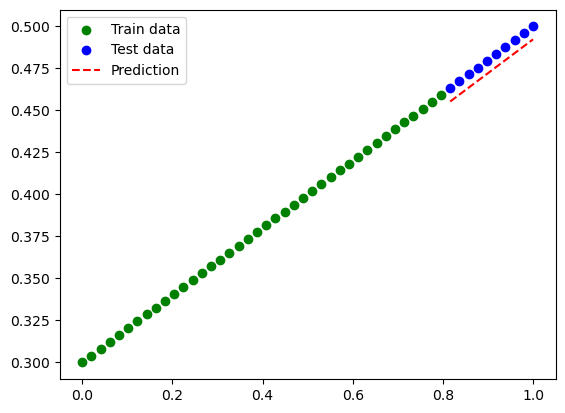

In [232]:
ourModel.eval()
with torch.inference_mode():
    y_preds=ourModel(x_test)
y_preds = y_preds.detach().cpu().numpy()
plt_predict(x_train, y_train, x_test, y_test, y_preds)

### making predictons